# Method 34 - Polar stereographic projection, 99th percentile 1980-2000 and 93.5th percentile 2000-2023 random sampling overflow bins and month distribution average cap

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.mixture import GaussianMixture
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from funcs import profileNo_vs_xy_bins, sample_cap_bins_xy, plot_geo, plot_heatmap_npts_xy, plot_3d, cross_sec_lon, cross_sec_lon_prob

In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

KeyboardInterrupt: 

In [3]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)
torch.manual_seed(seed)

In [4]:
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Depth_[m]']

In [5]:
# Break into two parts (1980-2000 and 2000-2023)
df_80_00 = df_ST[(df_ST['year'] >= 1980) & (df_ST['year'] < 2000)]
df_00_23 = df_ST[(df_ST['year'] >= 2000) & (df_ST['year'] < 2023)]

In [6]:
threshold_0 = profileNo_vs_xy_bins(df_80_00, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')

In [7]:
threshold_1 = profileNo_vs_xy_bins(df_00_23, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.935, projection='npstere')

In [8]:
df_sampled_0 = sample_cap_bins_xy(df_80_00, thresh=threshold_0, n_x_bins=100, n_y_bins=100)
df_sampled_1 = sample_cap_bins_xy(df_00_23, thresh=threshold_1, n_x_bins=100, n_y_bins=100)
df_sampled = pd.concat([df_sampled_0, df_sampled_1], ignore_index=True)

In [9]:
_ = profileNo_vs_xy_bins(df_sampled_0, n_x_bins=100, n_y_bins=100, show_threshold=False, projection='npstere')

In [10]:
# cap monthly distribution to average for whole sampled set
monthly_counts = df_sampled.groupby('month').size()
average_monthly_count = monthly_counts.mean()
df_sampled = df_sampled.groupby('month').apply(lambda x: x.sample(n=int(average_monthly_count), random_state=seed) if len(x) > average_monthly_count else x).reset_index(drop=True)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_31440/754394473.py:4: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [11]:
# Scale data
scaler = StandardScaler()
scaled_ST = scaler.fit_transform(df_sampled[features])

In [12]:
# Extract values into a tensor
X = torch.tensor(scaled_ST, dtype=torch.float32)
dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [13]:
# Define Variational Autoencoder

class VAE(nn.Module):
    def __init__(self, input_dim=3, latent_dim=2):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 16)
        self.fc3 = nn.Linear(16, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return self.fc3(h)     # no sigmoid for real-valued data

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [14]:
# Define loss function (mse and KL divergence)
def vae_loss(recon_x, x, mu, logvar):
    mse = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return mse + kld

In [15]:
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(input_dim=df_sampled[features].shape[1], latent_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
patience = 5
best_loss = float("inf")
patience_counter = 0
best_model_state = None

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for batch in loader:
        x = batch[0].to(device)
        optimizer.zero_grad()

        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

    # ---- Early stopping logic ----
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

Epoch 1 | Loss: 1.8847
Epoch 2 | Loss: 1.8724
Epoch 3 | Loss: 1.8711
Epoch 4 | Loss: 1.8704
Epoch 5 | Loss: 1.8705
Epoch 6 | Loss: 1.8693
Epoch 7 | Loss: 1.8692
Epoch 8 | Loss: 1.8692
Epoch 9 | Loss: 1.8695
Epoch 10 | Loss: 1.8704
Epoch 11 | Loss: 1.8699
Epoch 12 | Loss: 1.8691
Epoch 13 | Loss: 1.8691
Epoch 14 | Loss: 1.8693
Epoch 15 | Loss: 1.8691
Epoch 16 | Loss: 1.8697
Epoch 17 | Loss: 1.8691
Epoch 18 | Loss: 1.8696
Early stopping triggered at epoch 18


In [16]:
model.eval()
with torch.no_grad():
    mu, logvar = model.encode(X.to(device))
    z = mu.cpu()   # latent representation

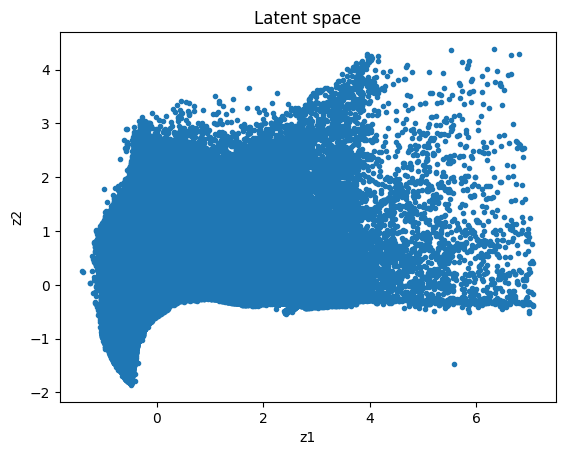

In [17]:
plt.scatter(z[:,0].cpu().tolist(), z[:,1].cpu().tolist(), marker='.')
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent space")
plt.show()

In [18]:
# Four clusters for comparison
n_clusters = 4

In [19]:
gmm = GaussianMixture(n_components=n_clusters, random_state=seed)
gmm.fit(z)
gmm_labels = gmm.predict(z)
df_sampled['gmm_label_4'] = gmm_labels.astype(int)

/Users/franciscagomes/PhD/WM_class/.venv/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning:


Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md




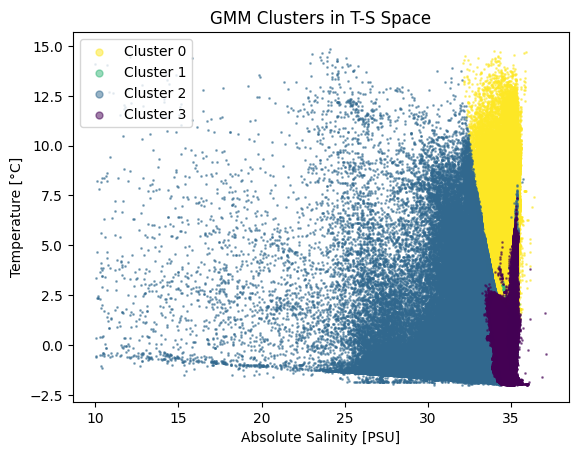

In [20]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_4'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [21]:
# Sample geographically for better plotting
df_sampled_plot = df_sampled.sample(n=70000, random_state=seed)
plot_geo(df_sampled_plot, n_clusters)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/TSD_M34/funcs.py:625: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



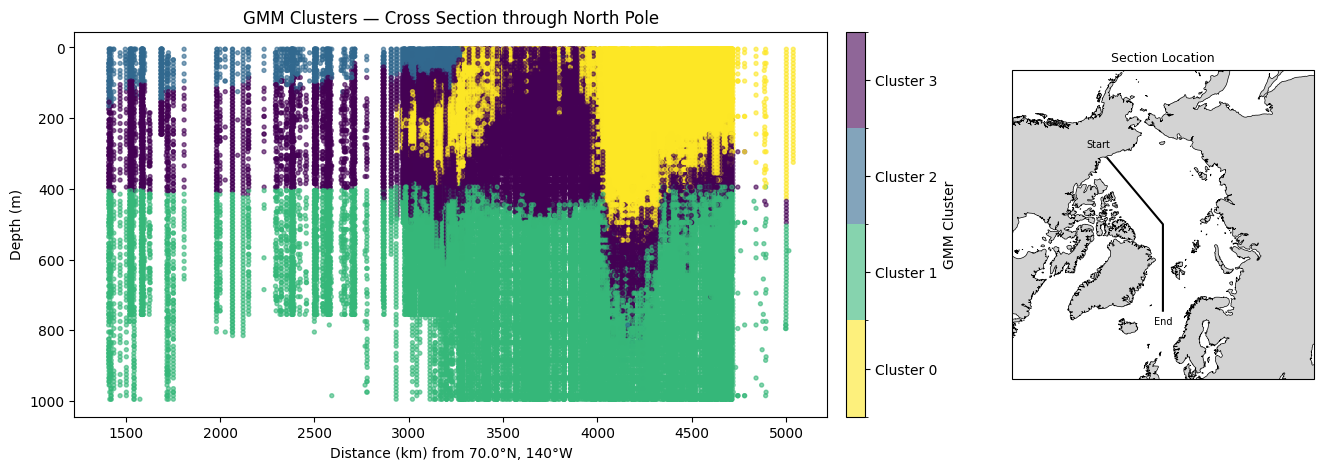

In [22]:
cross_sec_lon(df_sampled, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [23]:
# Get probabilities for each cluster
for i in range(n_clusters):
    df_sampled[f'prob_cluster_{i}'] = gmm.predict_proba(z)[:, i]

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/TSD_M34/funcs.py:717: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



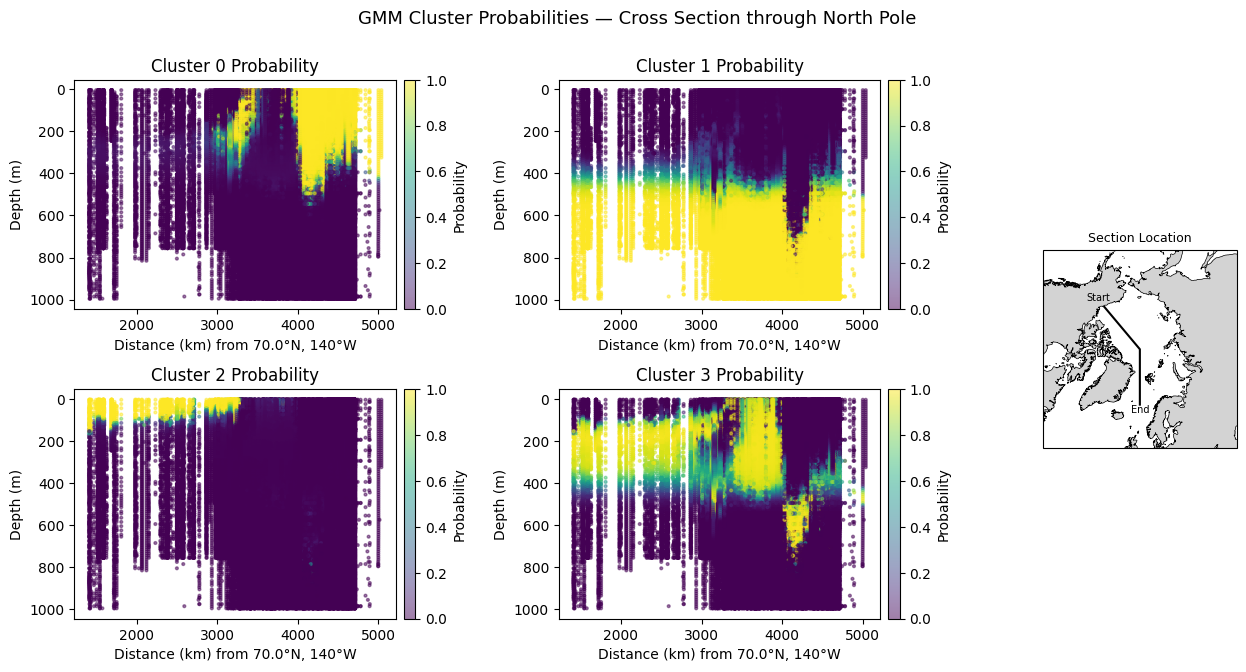

In [24]:
cross_sec_lon_prob(df_sampled, -180, tol=0.5, start_lat=70.0, start_lon=-140)